In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split,GridSearchCV,cross_val_score,KFold,LeaveOneOut,LeavePOut
from sklearn.tree import DecisionTreeRegressor,plot_tree
from sklearn.ensemble import RandomForestRegressor,VotingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

In [2]:
df=pd.read_csv("tips.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB


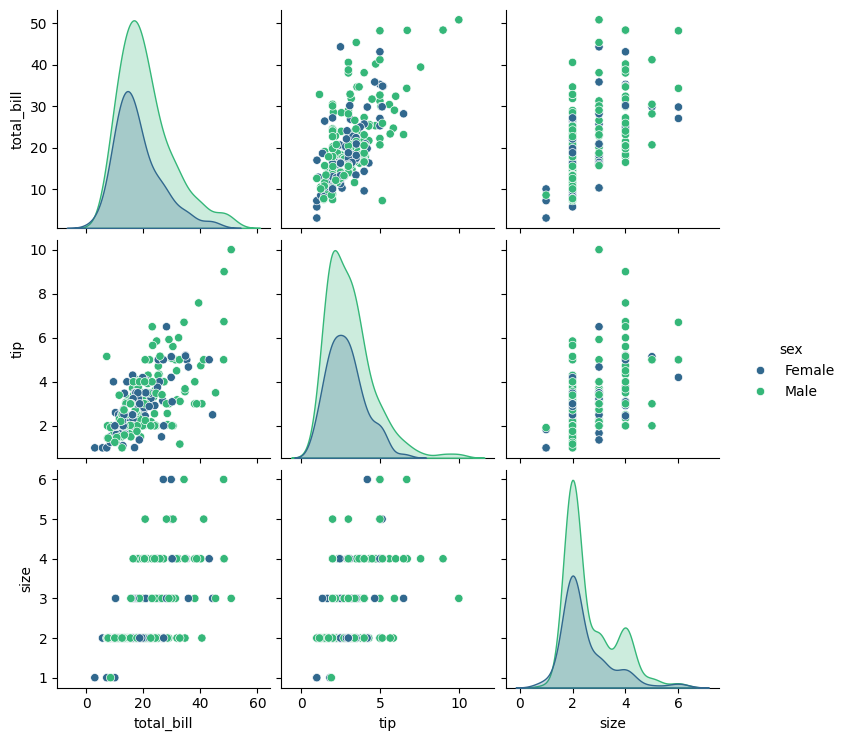

In [3]:
sns.pairplot(data=df,hue="sex",palette='viridis')
plt.show()

In [4]:
x=dict()
x["size"]=df["size"]
x=pd.DataFrame(x)

In [5]:
y=df[["tip"]]

In [6]:
x

,size
0,2
1,3
2,3
3,2
4,4
...,...
239,3
240,2
241,2
242,2


In [7]:
y

,tip
0,1.01
1,1.66
2,3.50
3,3.31
4,3.61
...,...
239,5.92
240,2.00
241,2.00
242,1.75


In [8]:
x_train,x_test,y_train,y_test=train_test_split(y,x,test_size=0.2,random_state=302)

In [9]:
param_grid = {
    'max_depth': [i for i in range(1,9,3)],
    'min_samples_split': [i for i in range(1,9,3)],
    'min_samples_leaf': [i for i in range(5)],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse', 'poisson'],
    'max_features':["auto","sqrt","log2"]
    }

In [10]:
dtr=DecisionTreeRegressor(criterion='absolute_error',max_depth= 1,min_samples_leaf= 1,min_samples_split= 4,max_features="sqrt")

In [11]:
loo=LeaveOneOut()
for train,test in enumerate(loo.split(x_train,y_train)):
    print(train,test)

0 (array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104,
       105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117,
       118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130,
       131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143,
       144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156,
       157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169,
       170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180,

In [12]:
p=cross_val_score(dtr,x_train,y_train,cv=LeavePOut(p=2))
p.max()

np.float64(1.0)

In [13]:
gc=GridSearchCV(estimator=dtr, param_grid=param_grid, scoring='accuracy',cv=KFold(n_splits=10))
gc.fit(x_train, y_train)

C:\Users\mitad\AppData\Roaming\Python\Python312\site-packages\sklearn\model_selection\_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\mitad\AppData\Roaming\Python\Python312\site-packages\sklearn\model_selection\_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\mitad\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_scorer.py", line 288, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\mitad\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_scorer.py", line 388, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs

GridSearchCV(cv=KFold(n_splits=10, random_state=None, shuffle=False),
             estimator=DecisionTreeRegressor(criterion='absolute_error',
                                             max_depth=1, max_features='sqrt',
                                             min_samples_split=4),
             param_grid={'criterion': ['squared_error', 'absolute_error',
                                       'friedman_mse', 'poisson'],
                         'max_depth': [1, 4, 7],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'min_samples_leaf': [0, 1, 2, 3, 4],
                         'min_samples_split': [1, 4, 7]},
             scoring='accuracy')

In [14]:
gc.best_score_

np.float64(0.6573684210526316)

In [15]:
gc.best_params_

{'criterion': 'absolute_error',
 'max_depth': 1,
 'max_features': 'sqrt',
 'min_samples_leaf': 1,
 'min_samples_split': 4}

In [16]:
dtr.fit(x_train,y_train)
dtr.score(x_test,y_test)

0.4130434782608695

In [17]:
rfr=RandomForestRegressor(n_estimators=246)
rfr.fit(x_train,y_train)
rfr.score(x_test,y_test)

C:\Users\mitad\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


0.33681923209329967

In [18]:
li=[("dt1",DecisionTreeRegressor(criterion='absolute_error',max_depth= 1,min_samples_leaf= 1,min_samples_split= 6,max_features="sqrt")),("sv",SVR(kernel="rbf")),("kn",KNeighborsRegressor(n_neighbors=4))]

In [19]:
vr=VotingRegressor(li)
vr.fit(x_train,y_train)
vr.score(x_test,y_test)

C:\Users\mitad\AppData\Roaming\Python\Python312\site-packages\sklearn\ensemble\_voting.py:698: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


0.44983502891892013

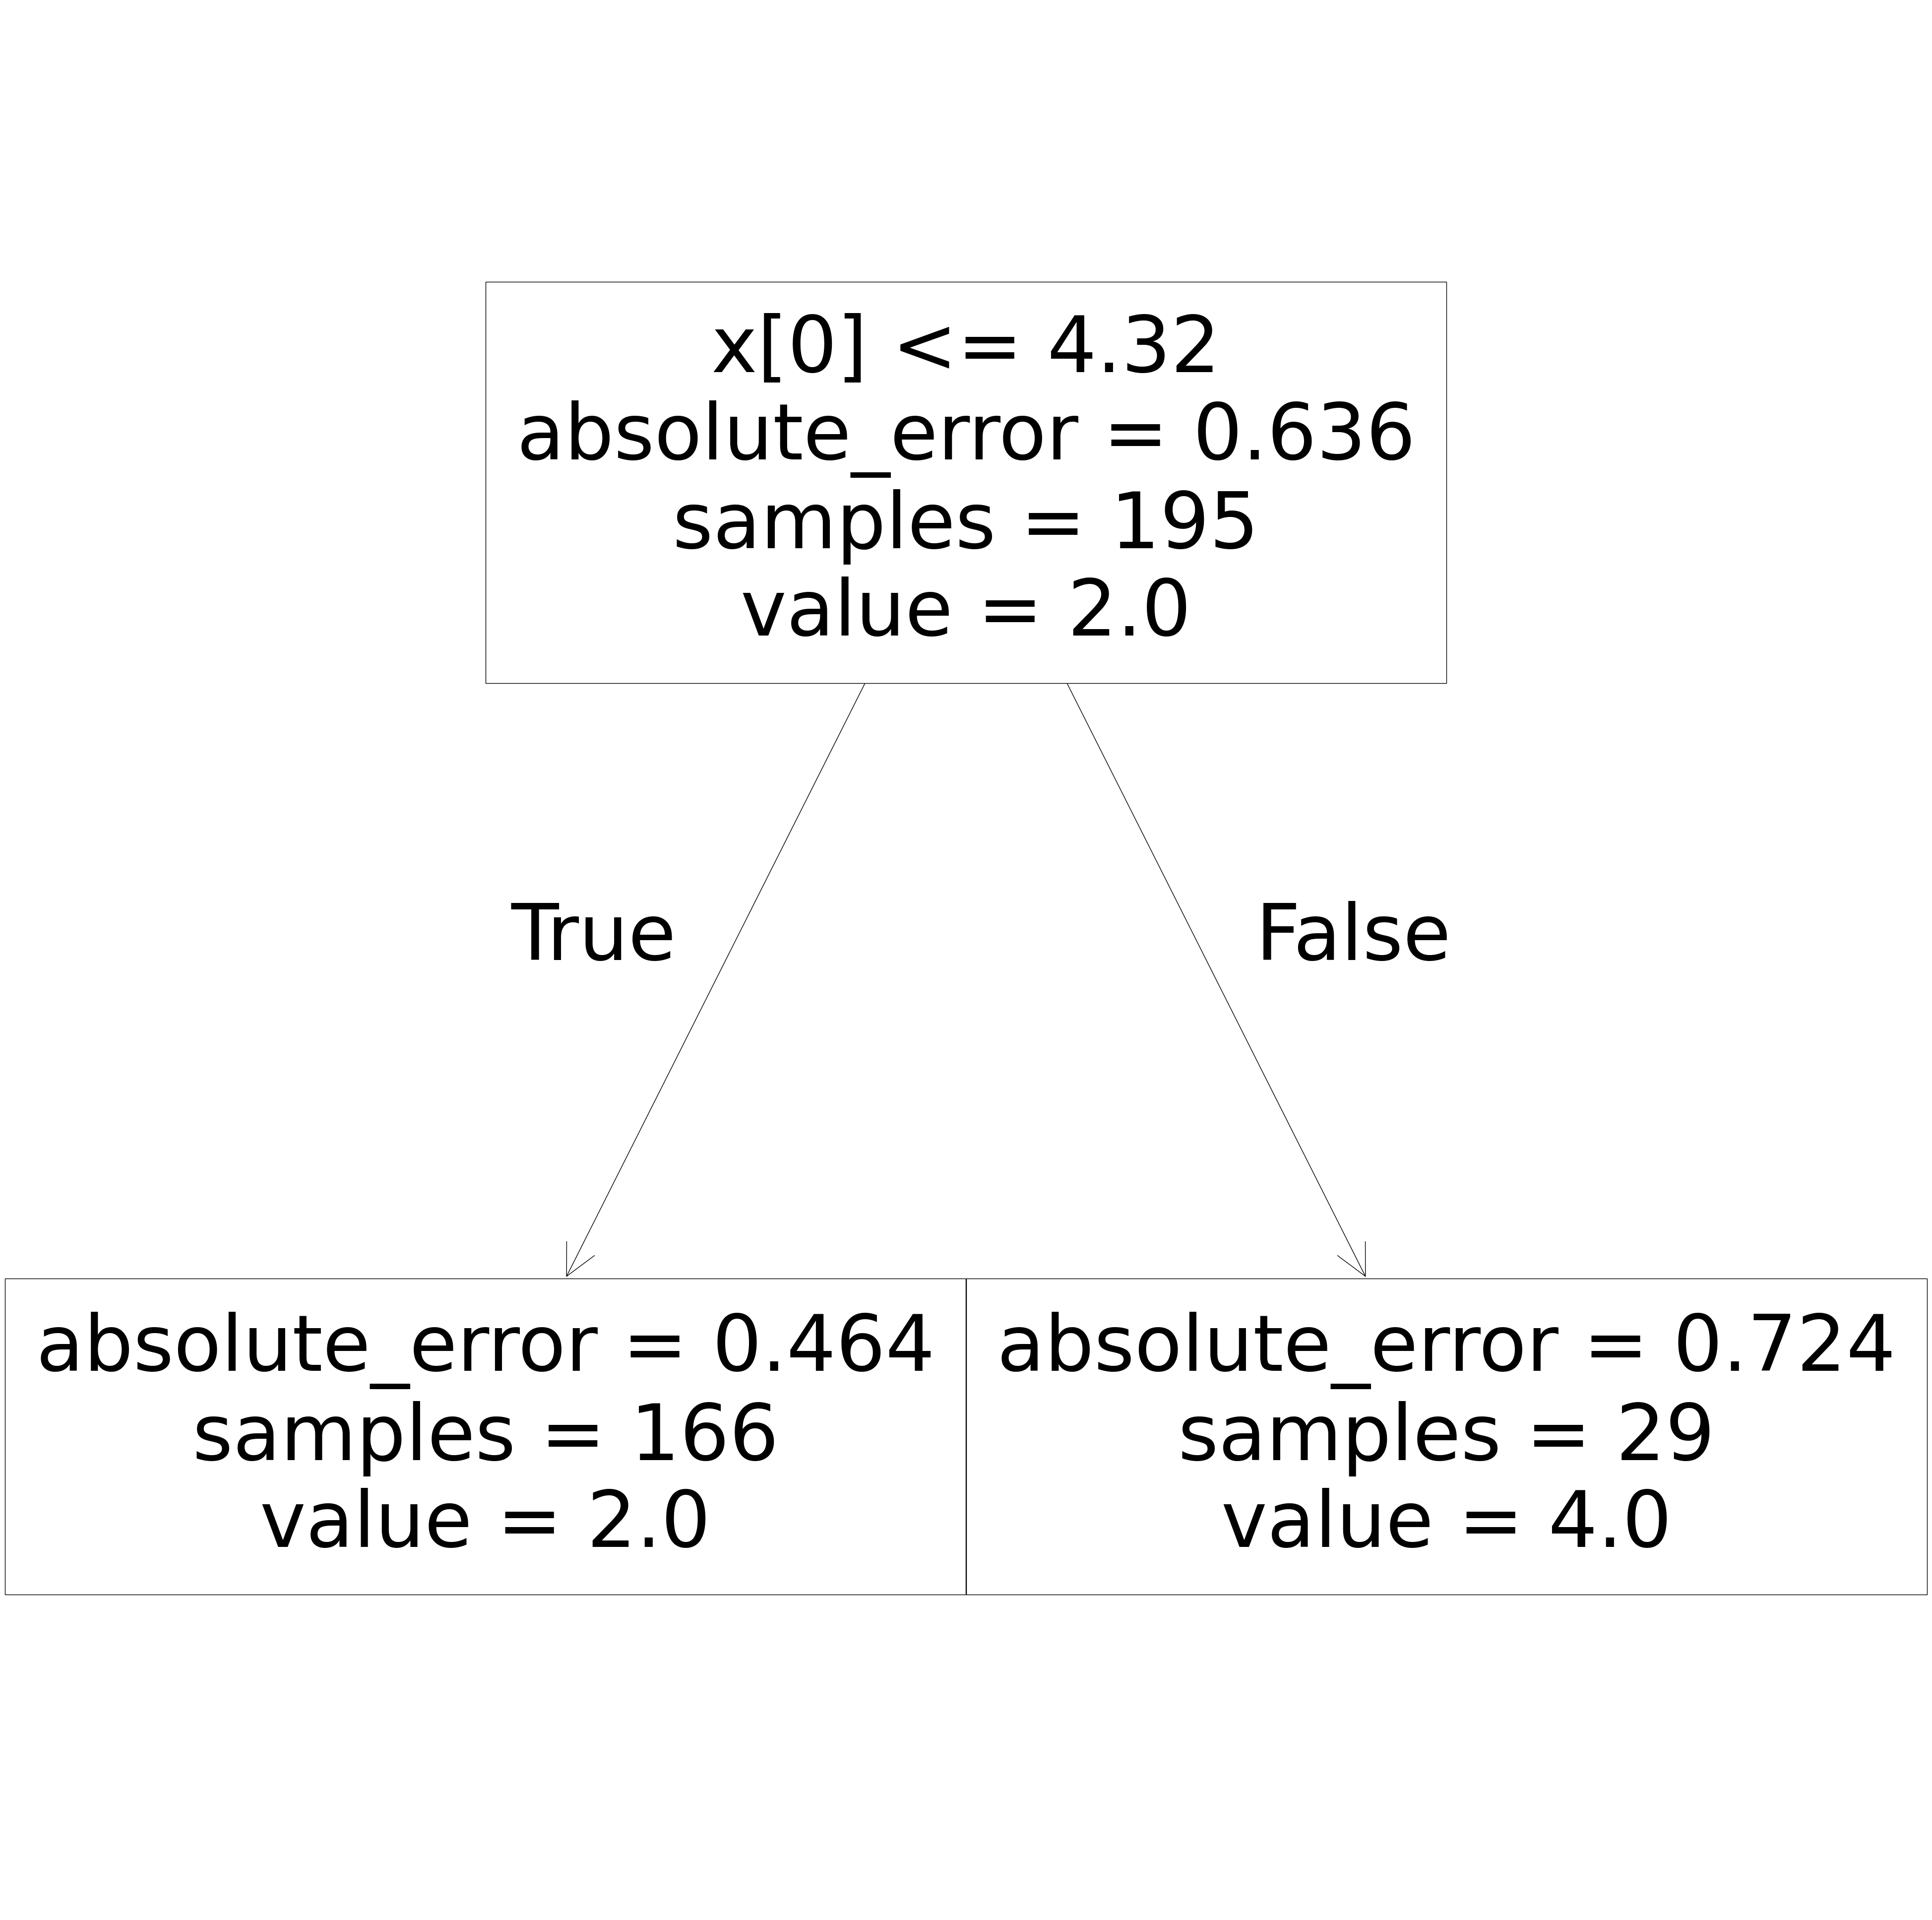

In [20]:
plt.figure(figsize=[50,50])
plot_tree(dtr)
plt.savefig("dtr.jpg")
plt.show()